# Business Performance Analysis & Reporting 📊
**Author:** Kajal Kumari &nbsp;|&nbsp; **GitHub:** [KAJAL-KR](https://github.com/KAJAL-KR)

---

## Overview
A business performance analysis project simulating the work of a **Junior Data Analyst** at a company tracking sales and customer data. SQL queries are used alongside Python for data extraction, and Matplotlib/Seaborn for visualization.

## Dataset Overview
- **Rows:** 1,194 transactions
- **Columns:** 12 (Order ID, Amount, Profit, Quantity, Category, Sub-Category, Payment Mode, City, State, Order Date, Year-Month, Customer)
- **Period:** 2020–2025

## Project Structure
| Step | Task |
|------|------|
| 1 | Load & Explore Dataset |
| 2 | Data Cleaning & Preprocessing |
| 3 | Operational Insights (SQL) |
| 4 | Product Analysis (SQL) |
| 5 | Data Visualization (4 charts) |
| 6 | Export Business Report (CSV) |

## Tools & Technologies
- **Language:** Python 3
- **Libraries:** Pandas · Matplotlib · Seaborn · SQLite3
- **Technique:** In-memory SQL queries via `sqlite3`
- **Environment:** Jupyter Notebook


---
## Step 1 — Load & Explore Dataset
Load the CSV into Pandas and inspect shape, data types, and summary statistics.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

data = pd.read_csv('Sales Dataset.csv')
print("Shape:", data.shape)
print("\nFirst 10 rows:")
print(data.head(10))


Shape: (1194, 12)

First 10 rows:
  Order ID  Amount  Profit  Quantity         Category      Sub-Category  \
0  B-26776    9726    1275         5      Electronics  Electronic Games   
1  B-26776    9726    1275         5      Electronics  Electronic Games   
2  B-26776    9726    1275         5      Electronics  Electronic Games   
3  B-26776    4975    1330        14      Electronics          Printers   
4  B-26776    4975    1330        14      Electronics          Printers   
5  B-26776    4975    1330        14      Electronics          Printers   
6  B-26942    1525     185        12  Office Supplies              Pens   
7  B-26942    1525     185        12  Office Supplies              Pens   
8  B-26640     883     117        10      Electronics           Laptops   
9  B-26640    8127    3551        16        Furniture            Tables   

   PaymentMode  Order Date    CustomerName       State         City Year-Month  
0          UPI  2023-06-27   David Padilla     Florida     

In [2]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1194 entries, 0 to 1193
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Order ID      1194 non-null   object
 1   Amount        1194 non-null   int64 
 2   Profit        1194 non-null   int64 
 3   Quantity      1194 non-null   int64 
 4   Category      1194 non-null   object
 5   Sub-Category  1194 non-null   object
 6   PaymentMode   1194 non-null   object
 7   Order Date    1194 non-null   object
 8   CustomerName  1194 non-null   object
 9   State         1194 non-null   object
 10  City          1194 non-null   object
 11  Year-Month    1194 non-null   object
dtypes: int64(3), object(9)
memory usage: 112.1+ KB


In [3]:
print("Summary Statistics:")
print(data.describe())


Summary Statistics:
            Amount       Profit     Quantity
count  1194.000000  1194.000000  1194.000000
mean   5178.089615  1348.992462    10.674204
std    2804.921955  1117.992573     5.777102
min     508.000000    50.000000     1.000000
25%    2799.000000   410.000000     6.000000
50%    5152.000000  1014.000000    11.000000
75%    7626.000000  2035.000000    16.000000
max    9992.000000  4930.000000    20.000000


---
## Step 2 — Data Cleaning & Preprocessing
- Check for missing values
- Convert `Order Date` to datetime format
- Remove duplicate rows


In [4]:
print("Missing Values:")
print(data.isnull().sum())


Missing Values:
Order ID        0
Amount          0
Profit          0
Quantity        0
Category        0
Sub-Category    0
PaymentMode     0
Order Date      0
CustomerName    0
State           0
City            0
Year-Month      0
dtype: int64


In [5]:
# Convert Order Date to datetime
data['Order Date'] = pd.to_datetime(data['Order Date'])

# Remove duplicates
before = len(data)
data = data.drop_duplicates()
after = len(data)

print(f"Data types updated. Duplicates removed: {before - after}")
print(data.info())


Data types updated. Duplicates removed: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1194 entries, 0 to 1193
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order ID      1194 non-null   object        
 1   Amount        1194 non-null   int64         
 2   Profit        1194 non-null   int64         
 3   Quantity      1194 non-null   int64         
 4   Category      1194 non-null   object        
 5   Sub-Category  1194 non-null   object        
 6   PaymentMode   1194 non-null   object        
 7   Order Date    1194 non-null   datetime64[ns]
 8   CustomerName  1194 non-null   object        
 9   State         1194 non-null   object        
 10  City          1194 non-null   object        
 11  Year-Month    1194 non-null   object        
dtypes: datetime64[ns](1), int64(3), object(8)
memory usage: 112.1+ KB
None


---
## Step 3 — Operational Insights (SQL)
Using in-memory SQLite to extract business insights directly from the dataset.

**Questions answered:**
- Which payment methods are used most frequently?
- Which cities generate the highest order volumes?
- What is the monthly order trend over time?


In [6]:
# Load data into in-memory SQLite
conn = sqlite3.connect(':memory:')
data.to_sql('sales', conn, index=False, if_exists='replace')

# Most frequently used payment methods
payment_query = '''
SELECT PaymentMode, COUNT(*) AS usage_count
FROM sales
GROUP BY PaymentMode
ORDER BY usage_count DESC
'''
payment_result = pd.read_sql_query(payment_query, conn)
print("💳 Most Frequently Used Payment Methods:")
print(payment_result)

# Top cities by order count
city_query = '''
SELECT City, COUNT(*) AS order_count
FROM sales
GROUP BY City
ORDER BY order_count DESC
LIMIT 10
'''
city_result = pd.read_sql_query(city_query, conn)
print("\n🌆 Top 10 Cities by Order Count:")
print(city_result)


💳 Most Frequently Used Payment Methods:
   PaymentMode  usage_count
0   Debit Card          260
1  Credit Card          258
2          UPI          252
3          EMI          218
4          COD          206

🌆 Top 10 Cities by Order Count:
            City  order_count
0        Buffalo           90
1  San Francisco           84
2        Orlando           77
3      Rochester           74
4      San Diego           73
5         Dallas           72
6      Cleveland           70
7    Springfield           68
8          Miami           66
9         Austin           65


In [7]:
# Monthly order volume
conn = sqlite3.connect(':memory:')
data.to_sql('sales', conn, index=False, if_exists='replace')

monthly_query = '''
SELECT "Year-Month", COUNT(*) as order_volume
FROM sales
GROUP BY "Year-Month"
ORDER BY "Year-Month"
'''
monthly_orders = pd.read_sql_query(monthly_query, conn)
print("📋 Monthly Order Volume:")
print(monthly_orders.to_string())


📋 Monthly Order Volume:
   Year-Month  order_volume
0     2020-03             4
1     2020-04            27
2     2020-05            22
3     2020-06            10
4     2020-07             9
5     2020-08            16
6     2020-09            20
7     2020-10            26
8     2020-11            21
9     2020-12            16
10    2021-01             9
11    2021-02            17
12    2021-03            19
13    2021-04            13
14    2021-05            20
15    2021-06            18
16    2021-07            14
17    2021-08            17
18    2021-09            12
19    2021-10            24
20    2021-11            28
21    2021-12            26
22    2022-01            31
23    2022-02            26
24    2022-03            19
25    2022-04            21
26    2022-05            23
27    2022-06            27
28    2022-07            16
29    2022-08            33
30    2022-09             9
31    2022-10            28
32    2022-11            10
33    2022-12           

---
## Step 4 — Product Analysis (SQL)
Identify pricing inefficiencies and top revenue-generating product categories.

**Questions answered:**
- Which sub-categories are expensive but sell in low quantities?
- Which sub-categories generate the most revenue?


In [8]:
conn = sqlite3.connect(':memory:')
data.to_sql('sales', conn, index=False, if_exists='replace')

# Expensive but low-volume products
expensive_query = '''
SELECT "Sub-Category",
       ROUND(AVG(Amount / Quantity), 2) AS avg_unit_price,
       SUM(Quantity) AS total_quantity
FROM sales
GROUP BY "Sub-Category"
ORDER BY avg_unit_price DESC
LIMIT 10
'''
expensive_result = pd.read_sql_query(expensive_query, conn)
print("📉 High-Price / Low-Volume Sub-Categories:")
print(expensive_result)


📉 High-Price / Low-Volume Sub-Categories:
       Sub-Category  avg_unit_price  total_quantity
0           Binders         1203.06             688
1            Phones         1059.06             980
2            Chairs         1038.61             875
3           Markers          989.38            1173
4             Sofas          959.01            1233
5             Paper          946.10             981
6              Pens          890.72            1204
7           Laptops          806.73             934
8  Electronic Games          792.07            1220
9            Tables          778.86            1303


In [9]:
conn = sqlite3.connect(':memory:')
data.to_sql('sales', conn, index=False, if_exists='replace')

# Top 10 sub-categories by revenue
top_products_query = '''
SELECT "Sub-Category", SUM(Amount) AS total_revenue
FROM sales
GROUP BY "Sub-Category"
ORDER BY total_revenue DESC
LIMIT 10
'''
top_products_result = pd.read_sql_query(top_products_query, conn)
print("🏆 Top 10 Sub-Categories by Revenue:")
print(top_products_result)


🏆 Top 10 Sub-Categories by Revenue:
       Sub-Category  total_revenue
0           Markers         627875
1            Tables         625177
2             Sofas         568367
3          Printers         566359
4  Electronic Games         565092
5              Pens         552269
6             Paper         524755
7            Phones         503055
8            Chairs         431964
9           Laptops         419950


---
## Step 5 — Data Visualization
Four business-focused charts communicating key performance insights.


### 5.1 — Top 10 Sub-Categories by Revenue

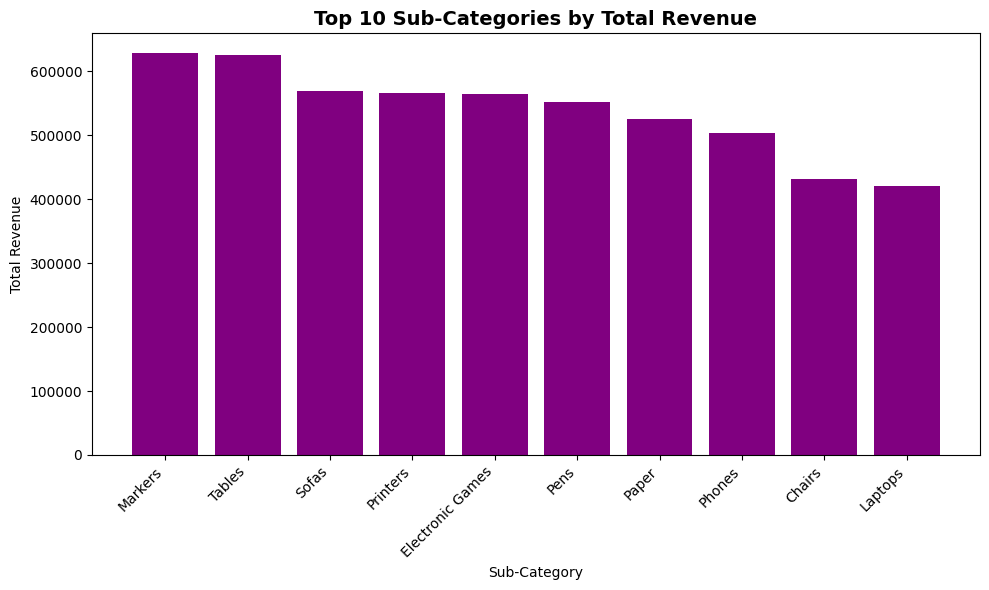

In [10]:
plt.figure(figsize=(10, 6))
plt.bar(top_products_result["Sub-Category"], top_products_result["total_revenue"], color="purple")
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Sub-Categories by Total Revenue", fontsize=14, fontweight='bold')
plt.xlabel("Sub-Category")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()


### 5.2 — Monthly Order Trend (2020–2025)

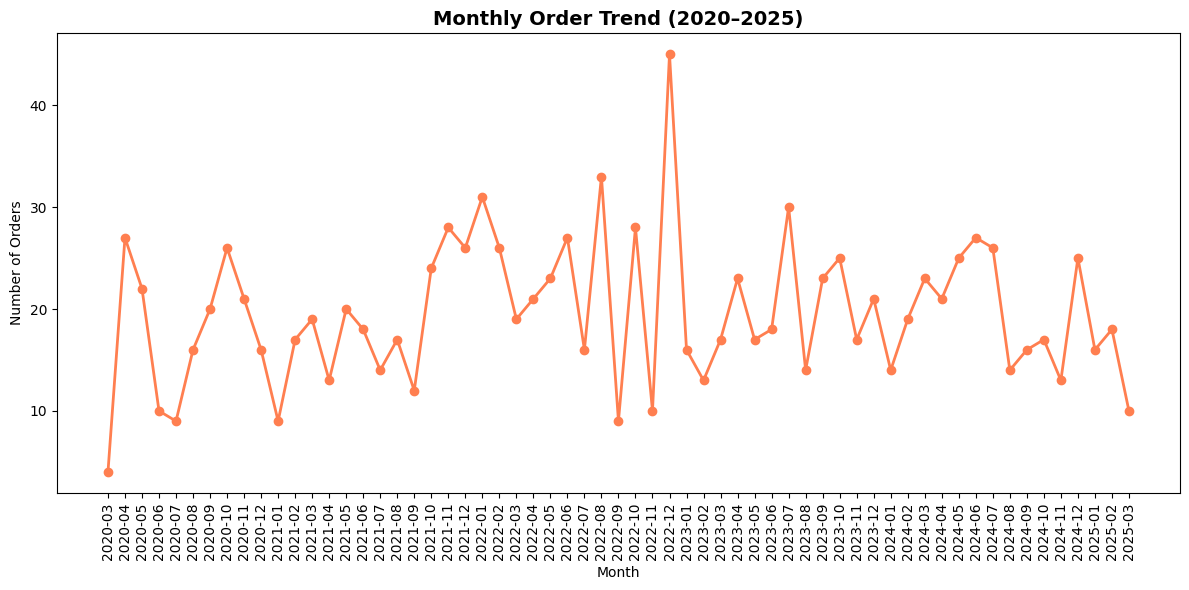

In [11]:
conn = sqlite3.connect(':memory:')
data.to_sql('sales', conn, index=False, if_exists='replace')

monthly_query = '''
SELECT "Year-Month", COUNT(*) AS order_count
FROM sales
GROUP BY "Year-Month"
ORDER BY "Year-Month"
'''
monthly_order_result = pd.read_sql_query(monthly_query, conn)

plt.figure(figsize=(12, 6))
plt.plot(monthly_order_result["Year-Month"], monthly_order_result["order_count"],
         marker="o", color="coral", linewidth=2)
plt.xticks(rotation=90)
plt.title("Monthly Order Trend (2020–2025)", fontsize=14, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()


### 5.3 — Top 10 States by Total Profit

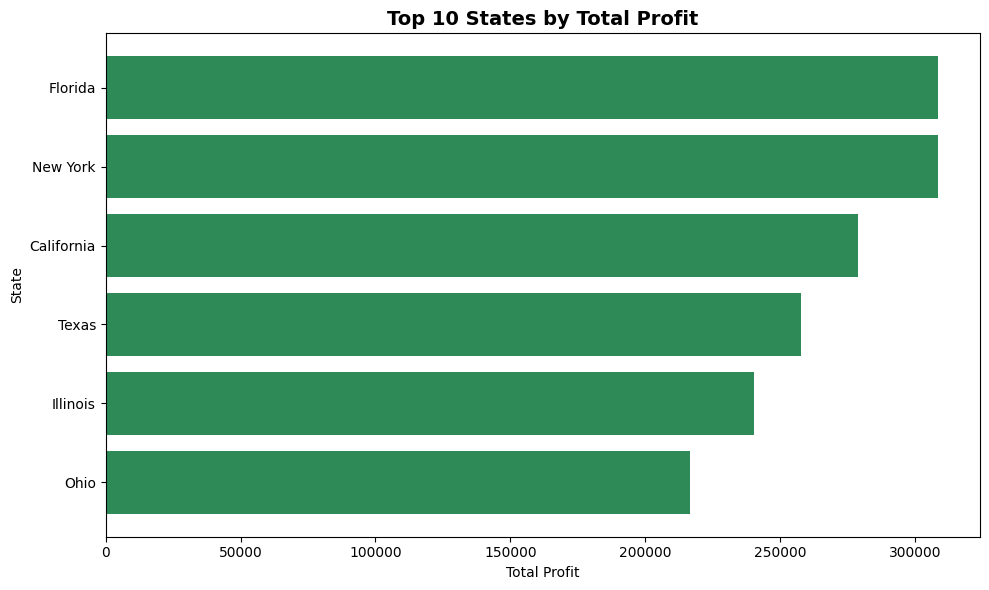

In [12]:
conn = sqlite3.connect(':memory:')
data.to_sql('sales', conn, index=False, if_exists='replace')

top_states_query = '''
SELECT State, SUM(Profit) AS total_profit
FROM sales
GROUP BY State
ORDER BY total_profit DESC
LIMIT 10
'''
top_states_result = pd.read_sql_query(top_states_query, conn)

plt.figure(figsize=(10, 6))
plt.barh(top_states_result["State"], top_states_result["total_profit"], color='seagreen')
plt.gca().invert_yaxis()
plt.title("Top 10 States by Total Profit", fontsize=14, fontweight='bold')
plt.xlabel("Total Profit")
plt.ylabel("State")
plt.tight_layout()
plt.show()


### 5.4 — Total Profit by Payment Mode

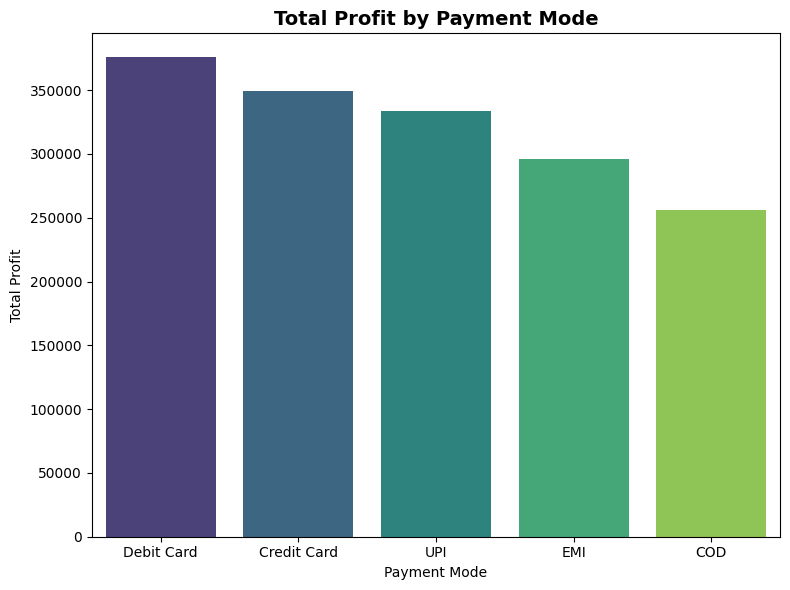

In [13]:
conn = sqlite3.connect(':memory:')
data.to_sql('sales', conn, index=False, if_exists='replace')

profit_payment_query = '''
SELECT PaymentMode, SUM(Profit) AS total_profit
FROM sales
GROUP BY PaymentMode
ORDER BY total_profit DESC
'''
profit_payment_result = pd.read_sql_query(profit_payment_query, conn)

plt.figure(figsize=(8, 6))
sns.barplot(x="PaymentMode", y="total_profit", data=profit_payment_result,
            hue="PaymentMode", palette="viridis", legend=False)
plt.title("Total Profit by Payment Mode", fontsize=14, fontweight='bold')
plt.xlabel("Payment Mode")
plt.ylabel("Total Profit")
plt.tight_layout()
plt.show()


---
## Step 6 — Export Business Reports
Save a combined report (top products + monthly orders) as CSV for stakeholders.


In [14]:
# Top 10 products by revenue
top_products = (
    data.groupby(['Category', 'Sub-Category'], dropna=False)['Amount']
    .sum()
    .reset_index()
    .sort_values('Amount', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top_products.columns = ["Top Product Category", "Sub-Category", "Total Revenue"]

# Monthly order summary
monthly_summary = (
    data.groupby('Year-Month')['Order ID']
    .count()
    .reset_index()
    .rename(columns={'Order ID': 'Order Count'})
)

# Combine and export
combined_data = pd.concat([top_products, monthly_summary], axis=1)
combined_data.to_csv("top_products_and_monthly_orders.csv", index=False)
print("Combined report exported: top_products_and_monthly_orders.csv")
print("\nCombined Report Preview:")
print(combined_data)


Combined report exported: top_products_and_monthly_orders.csv

Combined Report Preview:
   Top Product Category      Sub-Category  Total Revenue Year-Month  \
0       Office Supplies           Markers       627875.0    2020-03   
1             Furniture            Tables       625177.0    2020-04   
2             Furniture             Sofas       568367.0    2020-05   
3           Electronics          Printers       566359.0    2020-06   
4           Electronics  Electronic Games       565092.0    2020-07   
..                  ...               ...            ...        ...   
56                  NaN               NaN            NaN    2024-11   
57                  NaN               NaN            NaN    2024-12   
58                  NaN               NaN            NaN    2025-01   
59                  NaN               NaN            NaN    2025-02   
60                  NaN               NaN            NaN    2025-03   

    Order Count  
0             4  
1            27  
2    

---
## Key Business Insights Summary

| # | Insight | Recommendation |
|---|---------|----------------|
| 1 | Debit Card is the most used payment mode (260 transactions) | Prioritize debit card payment flows & offers |
| 2 | Markers & Tables are the top revenue-generating sub-categories | Increase inventory and promotions for these |
| 3 | Florida & New York lead all states in total profit | Focus regional marketing on these states |
| 4 | Debit Card also generates the highest total profit | Offer debit card exclusive discounts |
| 5 | Order volume shows clear seasonal trends (2020–2025) | Use peak months for campaign planning |

> **Key Skill Demonstrated:** This project uses **in-memory SQL via SQLite3** alongside Python —
> a technique used by real data analysts to run fast queries without a database server.
